# 05 · Compare takes

Same channel, different takes: spectra, band-level changes, and trigger rates side by side. Use it for
before/after-treatment, different concentrations, different days.

**Only compare like with like.** Absolute levels between takes mean something only if no sensor was
moved, re-mounted or re-gained in between. The change relative to each take's own baseline
(`delta_dB`) is much more robust.

In [1]:
# ==== YOUR SETTINGS ====
CONFIG = "../config/demo.yaml"
TAKES = None                  # None = all processed takes, or a list of names
CHANNEL = 1
BAND = "audio"
WINDOWS = {"early": (5.0, 30.0), "late": (60.0, 110.0)}   # [s] from each take's start
FMAX = 24000

In [2]:
# ---- standard setup (same in every notebook) ----
%matplotlib inline
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import zoom_acoustics as za
from zoom_acoustics import plots as zp, dsp

cfg = za.load_config(CONFIG)
print("config   :", cfg.config_file)
print("data_dir :", cfg.data_dir)
print("cache_dir:", cfg.cache_dir)
print("figures  :", cfg.figures_dir)

config   : /media/tmittal/Disk1/BKG_Data_Drive/zoom_acoustics_toolkit/config/demo.yaml
data_dir : /media/tmittal/Disk1/BKG_Data_Drive/zoom_acoustics_toolkit/demo_data/audio
cache_dir: /media/tmittal/Disk1/BKG_Data_Drive/zoom_acoustics_toolkit/demo_data/cache
figures  : /media/tmittal/Disk1/BKG_Data_Drive/zoom_acoustics_toolkit/demo_data/figures


In [3]:
feats = za.load_all_features(cfg)
if TAKES:
    feats = [f for f in feats if f.take in TAKES]
[f.take for f in feats]

['DEMO_001', 'DEMO_002', 'DEMO_003', 'DEMO_004']

[PosixPath('/media/tmittal/Disk1/BKG_Data_Drive/zoom_acoustics_toolkit/demo_data/figures/compare_psd_ch1.png')]

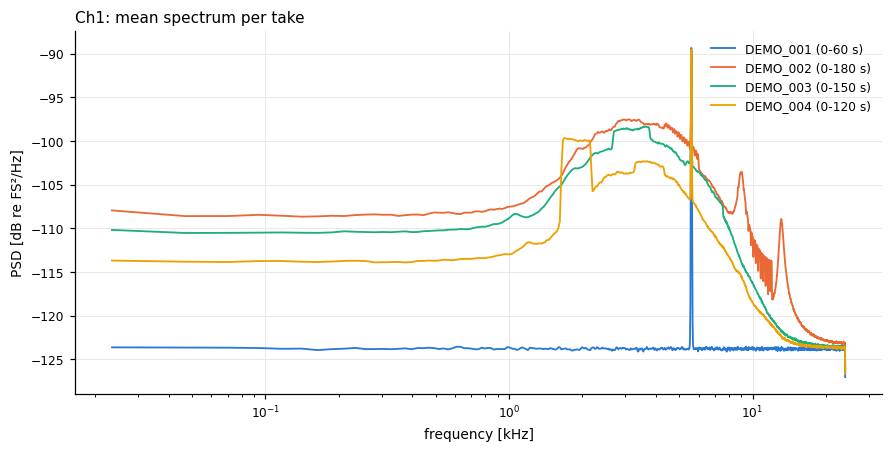

In [4]:
fig = zp.plot_compare_psd(feats, CHANNEL, fmax=FMAX)
zp.save(fig, cfg, f"compare_psd_ch{CHANNEL}")

In [5]:
tab = za.timeline.window_table(feats, WINDOWS, bands=[BAND])
tab.pivot_table(index=["take"], columns=["channel", "window"], values="level_dB").round(1)

channel      1           2           3           4      
window   early  late early  late early  late early  late
take                                                    
DEMO_001 -72.7   NaN -72.7   NaN -72.7   NaN -72.7   NaN
DEMO_002 -72.7 -60.2 -72.7 -65.3 -72.7 -66.9 -72.7 -72.7
DEMO_003 -62.8 -63.5 -67.3 -67.8   NaN   NaN   NaN   NaN
DEMO_004 -65.5 -65.9   NaN   NaN   NaN   NaN   NaN   NaN

[PosixPath('/media/tmittal/Disk1/BKG_Data_Drive/zoom_acoustics_toolkit/demo_data/figures/compare_delta.png')]

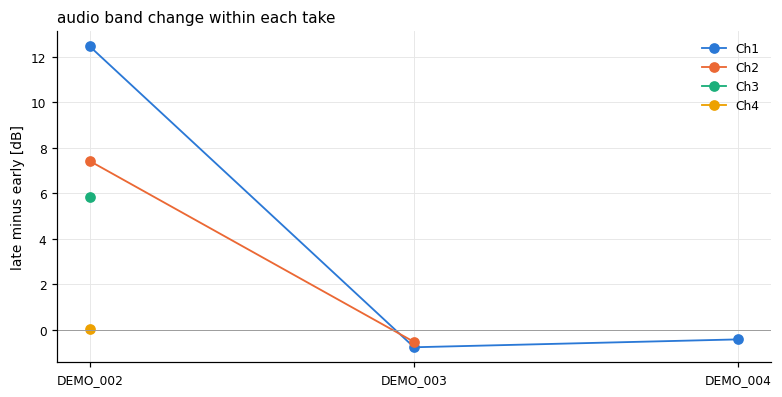

In [6]:
fig, ax = plt.subplots(figsize=(7, 3.5), constrained_layout=True)
sub = tab[tab["window"] == list(WINDOWS)[-1]]
for c in sorted(sub["channel"].unique()):
    s = sub[sub["channel"] == c]
    ax.plot(s["take"], s["delta_dB"], "o-", color=zp.ch_color(c), label=f"Ch{c}")
ax.set_ylabel(f"{list(WINDOWS)[-1]} minus {list(WINDOWS)[0]} [dB]")
ax.set_title(f"{BAND} band change within each take", loc="left")
ax.legend(); ax.axhline(0, color="0.6", lw=0.6)
zp.save(fig, cfg, "compare_delta")

In [7]:
rows = []
for f in feats:
    if CHANNEL in f.channels and BAND in f.meta["detect_bands"]:
        for w, (a, b) in WINDOWS.items():
            t, r, n, live = f.event_rate(CHANNEL, BAND, bin_s=1.0)
            m = (t >= a) & (t < b)
            rows.append(dict(take=f.take, window=w, triggers=int(n[m].sum()),
                             live_s=float(live[m].sum()),
                             rate_per_s=float(n[m].sum() / max(live[m].sum(), 1e-9))))
pd.DataFrame(rows).pivot_table(index="take", columns="window", values="rate_per_s").round(2)

window,early,late
take,,
DEMO_001,0.00,0.00
DEMO_002,0.00,25.79
DEMO_003,16.08,13.88
DEMO_004,7.80,6.48
